In [10]:
# ============================================================
# VOC 二分类：
# 固定开发集 A / 独立测试集 B
# A 内 10 次随机划分
# 每次划分独立训练 10 个模型
# 验证集选择冠军
# 10 个冠军统计稳定特征
# 稳定特征 > 60%
# 整个 A 重训最终模型
# 独立 TEST B 最终评价一次
# ============================================================


# ============================================================
# 0. Imports
# ============================================================

import os
import json
import copy
import random
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    TensorDataset,
)

import scipy.io as sio

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
)

import modules
importlib.reload(modules)

from utils import *
from modules import *


# ============================================================
# 1. 基础设置
# ============================================================

DTYPE = torch.float32

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("DEVICE =", DEVICE)


# ============================================================
# 2. 固定随机种子
# ============================================================

def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 3. 评价指标
# ============================================================

def compute_metrics(
    cm,
    targets,
    probs,
):

    tn = float(cm[0, 0])
    fp = float(cm[0, 1])

    fn = float(cm[1, 0])
    tp = float(cm[1, 1])

    eps = 1e-12

    sensitivity = (
        tp /
        (tp + fn + eps)
    )

    specificity = (
        tn /
        (tn + fp + eps)
    )

    ppv = (
        tp /
        (tp + fp + eps)
    )

    npv = (
        tn /
        (tn + fn + eps)
    )

    accuracy = (
        (tp + tn) /
        (
            tp +
            tn +
            fp +
            fn +
            eps
        )
    )

    f1 = (
        2 *
        ppv *
        sensitivity /
        (
            ppv +
            sensitivity +
            eps
        )
    )

    try:

        auc_value = roc_auc_score(
            targets,
            probs,
        )

    except ValueError:

        auc_value = np.nan

    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Accuracy": accuracy,
        "F1": f1,
        "AUC": auc_value,
    }


# ============================================================
# 4. 根据样本索引构建 DataLoader
# ============================================================

def build_loader(
    samples,
    labels,
    indices,
    batch_size=16,
    shuffle=False,
    drop_last=False,
):

    indices = np.asarray(
        indices,
        dtype=int,
    )

    dataset = TensorDataset(
        samples[indices],
        labels[indices],
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
    )

    return loader


# ============================================================
# 5. 使用固定 binary mask 进行预测
# ============================================================

def predict_with_mask(
    model,
    loader,
    binary_mask,
):

    model.eval()

    predictions = []
    probabilities = []
    targets = []

    binary_mask = binary_mask.to(
        DEVICE,
        dtype=DTYPE,
    )

    with torch.no_grad():

        for x, y in loader:

            x = x.to(
                DEVICE,
                dtype=DTYPE,
            )

            y = y.to(
                DEVICE
            ).long()

            outputs = model.mlp_classifier(
                x * binary_mask
            )

            probs = torch.softmax(
                outputs.float(),
                dim=1,
            )[:, 1]

            preds = outputs.argmax(
                dim=1
            )

            predictions.extend(
                preds
                .detach()
                .cpu()
                .numpy()
            )

            probabilities.extend(
                probs
                .detach()
                .cpu()
                .numpy()
            )

            targets.extend(
                y
                .detach()
                .cpu()
                .numpy()
            )

    return (
        np.asarray(predictions),
        np.asarray(probabilities),
        np.asarray(targets),
    )


# ============================================================
# 6. 训练一个候选模型
#
# 一个候选模型只使用：
#
# A'(i) -> 训练
# B'(i) -> 验证
#
# 独立 TEST B 完全不参与
# ============================================================

def train_candidate_model(
    train_loader,
    val_loader,
    x_val,
    k_means_mask,
    model_seed,
    epochs=30,
    sparsity_lambda=1e-2,
    temp_start=1.0,
    temp_end=0.3,
):

    set_seed(
        model_seed
    )

    model = MultiView(
        k_mean_mask=k_means_mask,
        num_blocks=4,
        head_dim=256,
        num_class=2,
        temperature=temp_start,
    ).to(
        DEVICE,
        dtype=DTYPE,
    )

    optimizer = optim.Adam(
        [
            {
                "params":
                    model.logist.parameters(),
                "lr":
                    1e-5,
                "weight_decay":
                    1e-4,
            },
            {
                "params":
                    model.mlp_classifier.parameters(),
                "lr":
                    5e-4,
                "weight_decay":
                    5e-3,
            },
        ]
    )

    criterion = (
        nn.CrossEntropyLoss()
    )

    best_val_acc = -1.0
    best_val_auc = -1.0
    best_val_f1 = -1.0

    best_state = None
    best_mask = None
    best_soft_score = None

    # ========================================================
    # Epoch
    # ========================================================

    for epoch in range(
        epochs
    ):

        # ----------------------------------------------------
        # 温度退火
        # ----------------------------------------------------

        model.temperature = (
            temp_start
            +
            (
                temp_end -
                temp_start
            )
            *
            (
                epoch /
                max(
                    1,
                    epochs - 1
                )
            )
        )

        # ----------------------------------------------------
        # Train
        # ----------------------------------------------------

        model.train()

        for x, y in train_loader:

            x = x.to(
                DEVICE,
                dtype=DTYPE,
            )

            y = y.to(
                DEVICE
            ).long()

            optimizer.zero_grad()

            outputs, _ = model(
                x
            )

            sparsity = (
                model
                .selection_prob(x)
                .mean()
            )

            loss = (
                criterion(
                    outputs,
                    y,
                )
                +
                sparsity_lambda
                *
                sparsity
            )

            loss.backward()

            optimizer.step()

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        model.eval()

        with torch.no_grad():

            # 当前模型二值特征 mask
            mask_eval = model.get_score(
                x_val.to(
                    DEVICE,
                    dtype=DTYPE,
                )
            )

            val_predictions = []
            val_probabilities = []
            val_targets = []

            for x, y in val_loader:

                x = x.to(
                    DEVICE,
                    dtype=DTYPE,
                )

                y = y.to(
                    DEVICE
                ).long()

                outputs = (
                    model.mlp_classifier(
                        x * mask_eval
                    )
                )

                probs = torch.softmax(
                    outputs.float(),
                    dim=1,
                )[:, 1]

                preds = outputs.argmax(
                    dim=1
                )

                val_predictions.extend(
                    preds
                    .cpu()
                    .numpy()
                )

                val_probabilities.extend(
                    probs
                    .cpu()
                    .numpy()
                )

                val_targets.extend(
                    y
                    .cpu()
                    .numpy()
                )

            val_predictions = np.asarray(
                val_predictions
            )

            val_probabilities = np.asarray(
                val_probabilities
            )

            val_targets = np.asarray(
                val_targets
            )

            val_cm = confusion_matrix(
                val_targets,
                val_predictions,
                labels=[0, 1],
            )

            val_metrics = compute_metrics(
                val_cm,
                val_targets,
                val_probabilities,
            )

            val_acc = (
                val_metrics[
                    "Accuracy"
                ]
            )

            val_auc = (
                val_metrics[
                    "AUC"
                ]
            )

            val_f1 = (
                val_metrics[
                    "F1"
                ]
            )

        # ----------------------------------------------------
        # 当前模型最佳 epoch
        #
        # 优先级：
        # Accuracy
        # -> AUC
        # -> F1
        # ----------------------------------------------------

        current_auc_for_compare = (
            -1.0
            if np.isnan(val_auc)
            else val_auc
        )

        best_auc_for_compare = (
            -1.0
            if np.isnan(best_val_auc)
            else best_val_auc
        )

        current_key = (
            val_acc,
            current_auc_for_compare,
            val_f1,
        )

        best_key = (
            best_val_acc,
            best_auc_for_compare,
            best_val_f1,
        )

        if current_key > best_key:

            best_val_acc = (
                val_acc
            )

            best_val_auc = (
                val_auc
            )

            best_val_f1 = (
                val_f1
            )

            best_state = copy.deepcopy(
                model.state_dict()
            )

            best_mask = (
                mask_eval
                .detach()
                .cpu()
                .clone()
            )

            best_soft_score = (
                model
                .selection_prob(
                    x_val.to(
                        DEVICE,
                        dtype=DTYPE,
                    )
                )
                .detach()
                .cpu()
                .numpy()
            )

    # ========================================================
    # 返回候选模型最佳结果
    # ========================================================

    if (
        best_state is None
        or best_mask is None
        or best_soft_score is None
    ):

        raise RuntimeError(
            "候选模型没有产生有效的最佳状态。"
        )

    return {
        "state_dict":
            best_state,

        "binary_mask":
            best_mask,

        "soft_score":
            best_soft_score,

        "val_acc":
            best_val_acc,

        "val_auc":
            best_val_auc,

        "val_f1":
            best_val_f1,

        "model_seed":
            model_seed,
    }


# ============================================================
# 7. 使用稳定特征，在整个开发集 A 上训练最终分类器
#
# 此时：
# stable_mask 已经完全固定
#
# 不重新进行特征选择
# ============================================================

def train_final_model(
    development_loader,
    k_means_mask,
    stable_mask,
    final_seed=42,
    epochs=30,
    temp_start=1.0,
):

    set_seed(
        final_seed
    )

    model = MultiView(
        k_mean_mask=k_means_mask,
        num_blocks=4,
        head_dim=256,
        num_class=2,
        temperature=temp_start,
    ).to(
        DEVICE,
        dtype=DTYPE,
    )

    # --------------------------------------------------------
    # 最终模型不再优化特征选择层
    # --------------------------------------------------------

    for parameter in (
        model.logist.parameters()
    ):

        parameter.requires_grad = False

    optimizer = optim.Adam(
        model
        .mlp_classifier
        .parameters(),
        lr=5e-4,
        weight_decay=5e-3,
    )

    criterion = (
        nn.CrossEntropyLoss()
    )

    stable_mask_device = (
        stable_mask.to(
            DEVICE,
            dtype=DTYPE,
        )
    )

    # ========================================================
    # Final training
    # ========================================================

    for epoch in range(
        epochs
    ):

        model.train()

        total_loss = 0.0
        total_samples = 0

        for x, y in (
            development_loader
        ):

            x = x.to(
                DEVICE,
                dtype=DTYPE,
            )

            y = y.to(
                DEVICE
            ).long()

            optimizer.zero_grad()

            outputs = (
                model.mlp_classifier(
                    x *
                    stable_mask_device
                )
            )

            loss = criterion(
                outputs,
                y,
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                *
                y.size(0)
            )

            total_samples += (
                y.size(0)
            )

        average_loss = (
            total_loss /
            max(
                total_samples,
                1
            )
        )

        print(
            f"Final model "
            f"epoch "
            f"{epoch + 1:02d}/"
            f"{epochs}, "
            f"loss = "
            f"{average_loss:.6f}"
        )

    return model


# ============================================================
# 8. Bootstrap ROC 95% CI
#
# 注意：
# 这里只对最终模型在 TEST B 上已经得到的
# target/probability 做统计重采样。
#
# 不重新训练模型，
# 不用 TEST 选择模型。
# ============================================================

def bootstrap_roc_confidence_interval(
    targets,
    probabilities,
    n_bootstrap=1000,
    seed=2068,
    confidence_level=0.95,
    n_grid=200,
):

    targets = np.asarray(
        targets
    )

    probabilities = np.asarray(
        probabilities
    )

    rng = (
        np.random.default_rng(
            seed
        )
    )

    mean_fpr = np.linspace(
        0.0,
        1.0,
        n_grid,
    )

    bootstrap_tprs = []
    bootstrap_aucs = []

    # --------------------------------------------------------
    # 为降低单一类别 bootstrap 的问题，
    # 在两个类别内部进行分层有放回抽样。
    # --------------------------------------------------------

    class_0_indices = np.where(
        targets == 0
    )[0]

    class_1_indices = np.where(
        targets == 1
    )[0]

    if (
        len(class_0_indices) == 0
        or
        len(class_1_indices) == 0
    ):

        return {
            "mean_fpr":
                mean_fpr,

            "lower_tpr":
                None,

            "upper_tpr":
                None,

            "bootstrap_aucs":
                np.asarray([]),

            "auc_ci_lower":
                np.nan,

            "auc_ci_upper":
                np.nan,
        }

    for _ in range(
        n_bootstrap
    ):

        sampled_class_0 = rng.choice(
            class_0_indices,
            size=len(
                class_0_indices
            ),
            replace=True,
        )

        sampled_class_1 = rng.choice(
            class_1_indices,
            size=len(
                class_1_indices
            ),
            replace=True,
        )

        sampled_indices = np.concatenate(
            [
                sampled_class_0,
                sampled_class_1,
            ]
        )

        rng.shuffle(
            sampled_indices
        )

        sampled_targets = targets[
            sampled_indices
        ]

        sampled_probs = probabilities[
            sampled_indices
        ]

        boot_fpr, boot_tpr, _ = (
            roc_curve(
                sampled_targets,
                sampled_probs,
            )
        )

        boot_auc = auc(
            boot_fpr,
            boot_tpr,
        )

        bootstrap_aucs.append(
            boot_auc
        )

        interp_tpr = np.interp(
            mean_fpr,
            boot_fpr,
            boot_tpr,
        )

        interp_tpr[0] = 0.0
        interp_tpr[-1] = 1.0

        bootstrap_tprs.append(
            interp_tpr
        )

    bootstrap_tprs = np.asarray(
        bootstrap_tprs
    )

    bootstrap_aucs = np.asarray(
        bootstrap_aucs
    )

    alpha = (
        1.0 -
        confidence_level
    )

    lower_percentile = (
        100 *
        alpha /
        2
    )

    upper_percentile = (
        100 *
        (
            1 -
            alpha /
            2
        )
    )

    lower_tpr = np.percentile(
        bootstrap_tprs,
        lower_percentile,
        axis=0,
    )

    upper_tpr = np.percentile(
        bootstrap_tprs,
        upper_percentile,
        axis=0,
    )

    auc_ci_lower = np.percentile(
        bootstrap_aucs,
        lower_percentile,
    )

    auc_ci_upper = np.percentile(
        bootstrap_aucs,
        upper_percentile,
    )

    return {
        "mean_fpr":
            mean_fpr,

        "lower_tpr":
            lower_tpr,

        "upper_tpr":
            upper_tpr,

        "bootstrap_aucs":
            bootstrap_aucs,

        "auc_ci_lower":
            auc_ci_lower,

        "auc_ci_upper":
            auc_ci_upper,
    }


# ============================================================
# 9. 主实验
# ============================================================

def experiment(
    data_path,
    save_path,
    num_cluster=3,

    # 开发集 A 内独立划分次数
    experiment_repeats=10,

    # 每个划分训练模型数量
    repeats=10,

    # 默认 epoch
    epochs=30,

    sparsity_lambda=1e-2,

    temp_start=1.0,
    temp_end=0.3,

    seed=42,

    # 严格超过 60%
    panel_threshold=0.6,

    batch_size=16,

    # ROC Bootstrap
    roc_bootstrap=1000,
):

    # ========================================================
    # 9.1 初始化
    # ========================================================

    set_seed(
        seed
    )

    out_dir = os.path.dirname(
        save_path
    )

    os.makedirs(
        out_dir,
        exist_ok=True,
    )

    # ========================================================
    # 9.2 读取数据
    # ========================================================

    data = sio.loadmat(
        data_path
    )

    samples = torch.tensor(
        data["X"],
        dtype=DTYPE,
    )

    labels = torch.tensor(
        data["y"],
        dtype=DTYPE,
    ).view(-1).long()

    voc_names = [
        str(
            value.flat[0]
        )
        for value
        in data[
            "feat_names"
        ].flatten()
    ]

    print("=" * 70)

    print(
        f"总样本数: "
        f"{samples.shape[0]}"
    )

    print(
        f"总 VOC 数: "
        f"{samples.shape[1]}"
    )

    print(
        f"类别: "
        f"{torch.unique(labels).tolist()}"
    )

    print("=" * 70)

    # ========================================================
    # 9.3 固定原始数据外层 A/B
    #
    # A = development set = 80%
    # B = independent test = 20%
    #
    # TEST B 后面不重新划分
    # ========================================================

    all_indices = np.arange(
        len(labels)
    )

    label_numpy = (
        labels
        .cpu()
        .numpy()
    )

    (
        development_indices,
        test_indices,
    ) = train_test_split(
        all_indices,
        test_size=0.20,
        random_state=seed,
        stratify=label_numpy,
    )

    development_indices = (
        np.asarray(
            development_indices,
            dtype=int,
        )
    )

    test_indices = (
        np.asarray(
            test_indices,
            dtype=int,
        )
    )

    print(
        f"开发集 A: "
        f"{len(development_indices)}"
    )

    print(
        f"独立测试集 B: "
        f"{len(test_indices)}"
    )

    # --------------------------------------------------------
    # 保存固定划分
    # --------------------------------------------------------

    np.savez(
        os.path.join(
            out_dir,
            "fixed_outer_split.npz",
        ),
        development_indices=
            development_indices,
        test_indices=
            test_indices,
    )

        # ========================================================
    # 9.4 k-means 只执行一次
    #
    # 规则：
    # 1. 只使用固定开发集 A
    # 2. TEST B 不参与
    # 3. 得到 View 划分后立即固定
    # 4. 后续所有 split / model / final model
    #    都复用同一个 k_means_mask
    # 5. 后续不允许再次调用 feature_cluster()
    # ========================================================

    print("\n")
    print("=" * 70)
    print("开始执行唯一一次 k-means / feature clustering")
    print("=" * 70)

    x_development = (
        samples[
            development_indices
        ]
        .float()
        .numpy()
    )

    k_means_mask = feature_cluster(
        x_development,
        num_cluster,
    )

    # 固定 k-means 得到的 View 划分
    fixed_k_means_mask = copy.deepcopy(
        k_means_mask
    )

    print(
        "k-means 已完成，"
        "后续所有重复实验固定使用同一 View 划分。"
    )

    print("=" * 70)

    # ========================================================
    # 9.5 A 内 10 次随机划分
    # ========================================================

    champion_masks = []
    champion_soft_scores = []
    champion_records = []

    development_labels = (
        label_numpy[
            development_indices
        ]
    )

    for split_idx in range(
        experiment_repeats
    ):

        print("\n")
        print("=" * 70)

        print(
            f"开发集随机划分 "
            f"{split_idx + 1}/"
            f"{experiment_repeats}"
        )

        print("=" * 70)

        split_seed = (
            seed
            + 1000
            + split_idx
        )

        (
            train_indices,
            val_indices,
        ) = train_test_split(
            development_indices,
            test_size=0.25,
            random_state=split_seed,
            stratify=development_labels,
        )

        train_indices = np.asarray(
            train_indices,
            dtype=int,
        )

        val_indices = np.asarray(
            val_indices,
            dtype=int,
        )

        train_loader = build_loader(
            samples,
            labels,
            train_indices,
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
        )

        val_loader = build_loader(
            samples,
            labels,
            val_indices,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

        x_val = samples[
            val_indices
        ]

        print(
            f"A'({split_idx + 1}) "
            f"训练样本: "
            f"{len(train_indices)}"
        )

        print(
            f"B'({split_idx + 1}) "
            f"验证样本: "
            f"{len(val_indices)}"
        )

        # ====================================================
        # 9.6 相同数据划分训练多个独立模型
        #
        # 注意：
        # 每个模型都使用完全相同的 fixed_k_means_mask
        # 不再重新执行 k-means
        # ====================================================

        group_best_result = None

        for model_idx in range(
            repeats
        ):

            model_seed = (
                seed
                + 100000
                + split_idx * 100
                + model_idx
            )

            print(
                f"\nSplit "
                f"{split_idx + 1:02d}"
                f" | Model "
                f"{model_idx + 1:02d}/"
                f"{repeats}"
                f" | seed="
                f"{model_seed}"
            )

            candidate = train_candidate_model(
                train_loader=train_loader,
                val_loader=val_loader,
                x_val=x_val,

                # 关键：
                # 所有模型共享同一个固定 View 划分
                k_means_mask=fixed_k_means_mask,

                model_seed=model_seed,
                epochs=epochs,
                sparsity_lambda=sparsity_lambda,
                temp_start=temp_start,
                temp_end=temp_end,
            )

            print(
                f"Val Accuracy = "
                f"{candidate['val_acc']:.4f}, "
                f"AUC = "
                f"{candidate['val_auc']:.4f}, "
                f"F1 = "
                f"{candidate['val_f1']:.4f}"
            )

            if group_best_result is None:

                group_best_result = candidate

            else:

                current_auc = (
                    -1.0
                    if np.isnan(
                        candidate["val_auc"]
                    )
                    else candidate["val_auc"]
                )

                best_auc = (
                    -1.0
                    if np.isnan(
                        group_best_result["val_auc"]
                    )
                    else group_best_result["val_auc"]
                )

                current_key = (
                    candidate["val_acc"],
                    current_auc,
                    candidate["val_f1"],
                )

                best_key = (
                    group_best_result["val_acc"],
                    best_auc,
                    group_best_result["val_f1"],
                )

                if current_key > best_key:
                    group_best_result = candidate
        # ====================================================
        # 9.7 当前数据划分冠军
        # ====================================================

        if group_best_result is None:

            raise RuntimeError(
                f"Split {split_idx + 1} "
                "没有产生冠军模型。"
            )

        champion_mask = (
            group_best_result[
                "binary_mask"
            ]
            .float()
        )

        champion_masks.append(
            champion_mask
        )

        champion_soft_scores.append(
            group_best_result[
                "soft_score"
            ]
        )

        selected_count = int(
            champion_mask
            .sum()
            .item()
        )

        champion_record = {

            "Split":
                split_idx + 1,

            "Split_Seed":
                split_seed,

            "Champion_Model_Seed":
                group_best_result[
                    "model_seed"
                ],

            "Val_Accuracy":
                group_best_result[
                    "val_acc"
                ],

            "Val_AUC":
                group_best_result[
                    "val_auc"
                ],

            "Val_F1":
                group_best_result[
                    "val_f1"
                ],

            "Selected_Feature_Count":
                selected_count,
        }

        champion_records.append(
            champion_record
        )

        # ----------------------------------------------------
        # 保存每一个冠军模型
        # ----------------------------------------------------

        champion_path = os.path.join(
            out_dir,
            (
                "champion_model_"
                f"split{split_idx + 1}.pt"
            ),
        )

        torch.save(
            {
                "split_idx":
                    split_idx,

                "split_seed":
                    split_seed,

                "model_seed":
                    group_best_result[
                        "model_seed"
                    ],

                "state_dict":
                    group_best_result[
                        "state_dict"
                    ],

                "binary_mask":
                    champion_mask,

                "soft_score":
                    group_best_result[
                        "soft_score"
                    ],

                "val_acc":
                    group_best_result[
                        "val_acc"
                    ],

                "val_auc":
                    group_best_result[
                        "val_auc"
                    ],

                "val_f1":
                    group_best_result[
                        "val_f1"
                    ],
            },

            champion_path,
        )

        print(
            "\n>>> 当前划分冠军"
        )

        print(
            champion_record
        )

    # ========================================================
    # 9.8 10 个冠军 -> 稳定特征
    # ========================================================

    champion_masks = (
        torch.stack(
            champion_masks,
            dim=0,
        )
    )

    torch.save(
        champion_masks,
        save_path,
    )

    champion_soft_scores = (
        np.stack(
            champion_soft_scores,
            axis=0,
        )
    )

    # --------------------------------------------------------
    # 二值 mask 选择频率
    # --------------------------------------------------------

    selection_frequency = (
        champion_masks
        .mean(dim=0)
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # Continuous soft importance
    # --------------------------------------------------------

    soft_mean = (
        champion_soft_scores
        .mean(axis=0)
    )

    soft_std = (
        champion_soft_scores
        .std(
            axis=0,
            ddof=0,
        )
    )

    soft_sem = (
        soft_std /
        np.sqrt(
            experiment_repeats
        )
    )

    # --------------------------------------------------------
    # 稳定 VOC：
    # Selection Frequency > 0.60
    #
    # 6/10 = 0.6 -> 不入选
    # 7/10 = 0.7 -> 入选
    # --------------------------------------------------------

    stable_feature_mask_numpy = (
        selection_frequency
        >
        panel_threshold
    )

    stable_feature_indices = np.where(
        stable_feature_mask_numpy
    )[0]

    stable_mask = torch.tensor(
        stable_feature_mask_numpy,
        dtype=DTYPE,
    )

    print("\n")
    print("=" * 70)

    print(
        f"稳定特征阈值: "
        f">{panel_threshold:.2f}"
    )

    print(
        f"稳定 VOC 数量: "
        f"{len(stable_feature_indices)}"
    )

    print("=" * 70)

    if (
        len(
            stable_feature_indices
        )
        ==
        0
    ):

        raise RuntimeError(
            "没有特征选择频率严格超过 "
            f"{panel_threshold:.2f}。"
        )

    # ========================================================
    # 9.9 保存冠军指标
    # ========================================================

    champion_df = pd.DataFrame(
        champion_records
    )

    champion_df.to_csv(
        os.path.join(
            out_dir,
            "champion_metrics.csv",
        ),
        index=False,
    )

    # ========================================================
    # 9.10 保存所有 VOC 统计
    # ========================================================

    selected_count_array = (
        champion_masks
        .sum(dim=0)
        .cpu()
        .numpy()
        .astype(int)
    )

    feature_stats_df = pd.DataFrame(
        {
            "VOC_Index":
                np.arange(
                    len(voc_names)
                ),

            "VOC_Name":
                voc_names,

            "Selected_Count":
                selected_count_array,

            "Selection_Frequency":
                selection_frequency,

            "Soft_Mean":
                soft_mean,

            "Soft_Std":
                soft_std,

            "Soft_SEM":
                soft_sem,

            "Stable":
                stable_feature_mask_numpy,
        }
    )

    feature_stats_df.to_csv(
        os.path.join(
            out_dir,
            "feature_selection_frequency.csv",
        ),
        index=False,
    )

    # ========================================================
    # 9.11 保存稳定 VOC Panel
    # ========================================================

    stable_features_df = (
        feature_stats_df[
            feature_stats_df[
                "Stable"
            ]
        ]
        .copy()
        .sort_values(
            [
                "Selection_Frequency",
                "Soft_Mean",
            ],
            ascending=[
                False,
                False,
            ],
        )
        .reset_index(
            drop=True
        )
    )

    stable_features_df.to_csv(
        os.path.join(
            out_dir,
            "stable_features.csv",
        ),
        index=False,
    )

    print(
        "\n稳定特征："
    )

    print(
        stable_features_df[
            [
                "VOC_Index",
                "VOC_Name",
                "Selected_Count",
                "Selection_Frequency",
            ]
        ].to_string(
            index=False
        )
    )

    # ========================================================
    # 9.12 使用整个开发集 A + 稳定特征
    #      重新训练最终模型
    #
    # 此处仍然没有使用 TEST B
    # ========================================================

    development_loader = build_loader(
        samples,
        labels,
        development_indices,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    print("\n")
    print("=" * 70)

    print(
        "开始使用整个开发集 A "
        "和稳定特征重新训练最终模型"
    )

    print("=" * 70)

    final_seed = (
        seed +
        999999
    )

    final_model = train_final_model(
        development_loader=
            development_loader,

        k_means_mask=
            fixed_k_means_mask,

        stable_mask=
            stable_mask,

        final_seed=
            final_seed,

        epochs=
            epochs,

        temp_start=
            temp_start,
    )

    # ========================================================
    # 9.13 现在才构建独立测试集 B
    # ========================================================

    test_loader = build_loader(
        samples,
        labels,
        test_indices,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    print("\n")
    print("=" * 70)

    print(
        "现在开始第一次、也是唯一一次 "
        "独立测试集 B 评价"
    )

    print("=" * 70)

    # ========================================================
    # 9.14 TEST B 最终评价
    # ========================================================

    (
        test_predictions,
        test_probabilities,
        test_targets,
    ) = predict_with_mask(
        model=
            final_model,

        loader=
            test_loader,

        binary_mask=
            stable_mask,
    )

    test_cm = confusion_matrix(
        test_targets,
        test_predictions,
        labels=[0, 1],
    )

    test_metrics = compute_metrics(
        test_cm,
        test_targets,
        test_probabilities,
    )

    # ========================================================
    # 9.15 保存最终 TEST 指标
    # ========================================================

    final_test_metrics_df = pd.DataFrame(
        [
            {
                "Test_Samples":
                    len(
                        test_targets
                    ),

                "Stable_Feature_Count":
                    len(
                        stable_feature_indices
                    ),

                "Threshold":
                    panel_threshold,

                **test_metrics,
            }
        ]
    )

    final_test_metrics_df.to_csv(
        os.path.join(
            out_dir,
            "final_test_metrics.csv",
        ),
        index=False,
    )

    # ========================================================
    # 9.16 TEST 混淆矩阵
    # ========================================================

    pd.DataFrame(
        test_cm,
        index=[
            "True_Class_0",
            "True_Class_1",
        ],
        columns=[
            "Pred_Class_0",
            "Pred_Class_1",
        ],
    ).to_csv(
        os.path.join(
            out_dir,
            "final_test_confusion_matrix.csv",
        )
    )

    # ========================================================
    # 9.17 TEST 每个样本结果
    # ========================================================

    test_predictions_df = pd.DataFrame(
        {
            "Test_Index":
                np.arange(
                    len(
                        test_targets
                    )
                ),

            "Target":
                test_targets,

            "Probability_Class1":
                test_probabilities,

            "Prediction":
                test_predictions,
        }
    )

    test_predictions_df.to_csv(
        os.path.join(
            out_dir,
            "final_test_predictions.csv",
        ),
        index=False,
    )

    # ========================================================
    # 9.18 保存最终模型
    # ========================================================

    torch.save(
        {
            "state_dict":
                final_model
                .state_dict(),

            "stable_mask":
                stable_mask,

            "stable_feature_indices":
                stable_feature_indices,

            "seed":
                final_seed,
        },

        os.path.join(
            out_dir,
            "final_model.pt",
        ),
    )

    # ========================================================
    # 9.19 ROC Bootstrap
    # ========================================================

    bootstrap_result = (
        bootstrap_roc_confidence_interval(
            targets=
                test_targets,

            probabilities=
                test_probabilities,

            n_bootstrap=
                roc_bootstrap,

            seed=
                seed + 2026,

            confidence_level=
                0.95,

            n_grid=
                200,
        )
    )

    # ========================================================
    # 9.20 保存配置
    # ========================================================

    config = {

        "seed":
            seed,

        "num_cluster":
            num_cluster,

        "outer_split": {
            "development":
                0.8,

            "test":
                0.2,
        },

        "inner_split": {
            "train":
                0.75,

            "validation":
                0.25,
        },

        "inner_splits":
            experiment_repeats,

        "models_per_split":
            repeats,

        "total_candidate_models":
            (
                experiment_repeats *
                repeats
            ),

        "epochs":
            epochs,

        "batch_size":
            batch_size,

        "sparsity_lambda":
            sparsity_lambda,

        "temp_start":
            temp_start,

        "temp_end":
            temp_end,

        "stable_feature_threshold":
            panel_threshold,

        "stable_feature_rule":
            (
                "Selection_Frequency "
                f"> {panel_threshold}"
            ),

        "test_used_for_model_selection":
            False,

        "test_evaluation_count":
            1,

        "unknown_features_removed":
            False,

        "roc_bootstrap": {
            "enabled":
                True,

            "n_bootstrap":
                roc_bootstrap,

            "confidence_level":
                0.95,

            "seed":
                seed + 2026,
        },

        "torch_version":
            torch.__version__,

        "numpy_version":
            np.__version__,
    }

    with open(
        os.path.join(
            out_dir,
            "run_config.json",
        ),
        "w",
        encoding="utf-8",
    ) as file:

        json.dump(
            config,
            file,
            indent=2,
            ensure_ascii=False,
        )

    # ========================================================
    # 10. VOC 图
    #
    # 恢复旧版形式：
    #
    # 上：
    # Selection Frequency
    #
    # 下：
    # Soft Importance + SEM + Std
    # ========================================================

    sorted_idx = np.lexsort(
        (
            soft_mean,
            selection_frequency,
        )
    )[::-1]

    stable_sorted_idx = np.asarray(
        [
            idx
            for idx
            in sorted_idx

            if (
                selection_frequency[
                    idx
                ]
                >
                panel_threshold
            )
        ],
        dtype=int,
    )

    top_n = len(
        stable_sorted_idx
    )

    if top_n > 0:

        selection_plot = (
            selection_frequency[
                stable_sorted_idx
            ]
        )

        soft_plot = (
            soft_mean[
                stable_sorted_idx
            ]
        )

        std_plot = (
            soft_std[
                stable_sorted_idx
            ]
        )

        sem_plot = (
            soft_sem[
                stable_sorted_idx
            ]
        )

        fig1, axes = plt.subplots(
            2,
            1,
            figsize=(
                16,
                8,
            ),
        )

        # ----------------------------------------------------
        # 上图：Selection Frequency
        # ----------------------------------------------------

        axes[0].bar(
            range(top_n),
            selection_plot,
            color="teal",
            alpha=0.7,
        )

        axes[0].axhline(
            y=panel_threshold,
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=(
                f"Threshold "
                f"{panel_threshold:.1f}"
            ),
        )

        axes[0].set_title(
            (
                f"Top {top_n} Stable VOC "
                f"Selection Frequency "
                f"(n={experiment_repeats} "
                f"champion models)"
            ),
            fontsize=14,
        )

        axes[0].set_ylabel(
            "Selection Frequency",
            fontsize=12,
        )

        axes[0].set_ylim(
            0.0,
            1.05,
        )

        axes[0].legend(
            loc="upper right",
        )

        # ----------------------------------------------------
        # 下图：Soft Importance
        # ----------------------------------------------------

        axes[1].bar(
            range(top_n),
            soft_plot,
            color="coral",
            alpha=0.60,
            label=(
                "Soft Importance "
                "σ(θ)"
            ),
        )

        axes[1].fill_between(
            range(top_n),
            soft_plot - sem_plot,
            soft_plot + sem_plot,
            color="gray",
            alpha=0.35,
            label="± SEM",
        )

        axes[1].errorbar(
            range(top_n),
            soft_plot,
            yerr=std_plot,
            fmt="none",
            ecolor="black",
            capsize=2,
            alpha=0.50,
            label="Std Dev",
        )

        axes[1].set_title(
            (
                f"Soft Importance of "
                f"Top {top_n} Stable VOC "
                f"Features "
                f"(Ordered by Selection Frequency)"
            ),
            fontsize=14,
        )

        axes[1].set_ylabel(
            "σ(θ)",
            fontsize=12,
        )

        axes[1].set_xlabel(
            "VOC Index (Ranked)",
            fontsize=12,
        )

        axes[1].legend(
            loc="upper right",
        )

        fig1.tight_layout()

        voc_figure_path = (
            os.path.join(
                out_dir,
                "stable_feature_importance.png",
            )
        )

        fig1.savefig(
            voc_figure_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print(
            f"[保存] VOC 图 → "
            f"{voc_figure_path}"
        )

    # ========================================================
    # 11. 最终模型 TEST ROC
    #
    # Final ROC
    # +
    # 95% Bootstrap CI 蓝色区域
    # ========================================================

    if (
        len(
            np.unique(
                test_targets
            )
        )
        ==
        2
    ):

        fpr, tpr, _ = roc_curve(
            test_targets,
            test_probabilities,
        )

        test_auc = auc(
            fpr,
            tpr,
        )

        mean_fpr = (
            bootstrap_result[
                "mean_fpr"
            ]
        )

        lower_tpr = (
            bootstrap_result[
                "lower_tpr"
            ]
        )

        upper_tpr = (
            bootstrap_result[
                "upper_tpr"
            ]
        )

        bootstrap_aucs = (
            bootstrap_result[
                "bootstrap_aucs"
            ]
        )

        auc_ci_lower = (
            bootstrap_result[
                "auc_ci_lower"
            ]
        )

        auc_ci_upper = (
            bootstrap_result[
                "auc_ci_upper"
            ]
        )

        # ----------------------------------------------------
        # 保存 Bootstrap AUC
        # ----------------------------------------------------

        pd.DataFrame(
            {
                "Bootstrap_AUC":
                    bootstrap_aucs
            }
        ).to_csv(
            os.path.join(
                out_dir,
                "final_test_auc_bootstrap.csv",
            ),
            index=False,
        )

        # ----------------------------------------------------
        # 保存 ROC CI
        # ----------------------------------------------------

        if (
            lower_tpr is not None
            and
            upper_tpr is not None
        ):

            pd.DataFrame(
                {
                    "FPR":
                        mean_fpr,

                    "TPR_CI95_Lower":
                        lower_tpr,

                    "TPR_CI95_Upper":
                        upper_tpr,
                }
            ).to_csv(
                os.path.join(
                    out_dir,
                    "final_test_roc_bootstrap_ci.csv",
                ),
                index=False,
            )

        # ----------------------------------------------------
        # ROC Plot
        # ----------------------------------------------------

        fig2, ax = plt.subplots(
            figsize=(
                8,
                8,
            )
        )

        # 蓝色 95% CI 区域
        if (
            lower_tpr is not None
            and
            upper_tpr is not None
        ):

            ax.fill_between(
                mean_fpr,
                lower_tpr,
                upper_tpr,
                color="steelblue",
                alpha=0.25,
                label=(
                    "95% Bootstrap CI"
                ),
            )

        # 最终 ROC 曲线
        ax.plot(
            fpr,
            tpr,
            color="navy",
            linewidth=3,
            label=(
                f"Final ROC "
                f"(AUC = "
                f"{test_auc:.3f})"
            ),
        )

        # 随机分类线
        ax.plot(
            [0, 1],
            [0, 1],
            "k--",
            linewidth=1.5,
            label="Chance",
        )

        ax.set_xlabel(
            "False Positive Rate",
            fontsize=16,
        )

        ax.set_ylabel(
            "True Positive Rate",
            fontsize=16,
        )

        ax.set_title(
            (
                "ROC Curve "
                "(Final Model, "
                "Independent TEST B)"
            ),
            fontsize=18,
        )

        ax.set_xlim(
            0.0,
            1.0,
        )

        ax.set_ylim(
            0.0,
            1.02,
        )

        ax.tick_params(
            axis="both",
            labelsize=13,
        )

        ax.legend(
            loc="lower right",
            fontsize=12,
        )

        fig2.tight_layout()

        roc_figure_path = (
            os.path.join(
                out_dir,
                "final_test_roc.png",
            )
        )

        fig2.savefig(
            roc_figure_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

        print(
            f"[保存] Final TEST ROC → "
            f"{roc_figure_path}"
        )

        print(
            f"TEST AUC = "
            f"{test_auc:.4f}"
        )

        if (
            not np.isnan(
                auc_ci_lower
            )
        ):

            print(
                "TEST AUC "
                "95% Bootstrap CI = "
                f"["
                f"{auc_ci_lower:.4f}, "
                f"{auc_ci_upper:.4f}"
                f"]"
            )

    # ========================================================
    # 12. 最终报告
    #
    # 注意：
    # 这一部分必须在 ROC if 外面
    # ========================================================

    print("\n")
    print("=" * 70)

    print(
        "FINAL INDEPENDENT TEST B REPORT"
    )

    print("=" * 70)

    print(
        f"测试样本数: "
        f"{len(test_targets)}"
    )

    print(
        f"稳定特征数: "
        f"{len(stable_feature_indices)}"
    )

    print(
        f"{experiment_repeats} 次划分 × "
        f"{repeats} 个模型 = "
        f"{experiment_repeats * repeats} "
        f"个候选模型"
    )

    print("-" * 70)

    for metric_name in [
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Accuracy",
        "F1",
        "AUC",
    ]:

        print(
            f"{metric_name:<15}"
            f"{test_metrics[metric_name]:.4f}"
        )

    print("-" * 70)

    print(
        "Confusion Matrix:"
    )

    print(
        test_cm
    )

    print("=" * 70)

    # ========================================================
    # 13. Return
    # ========================================================

    return {

        "champion_metrics":
            champion_df,

        "feature_stats":
            feature_stats_df,

        "stable_features":
            stable_features_df,

        "stable_mask":
            stable_mask,

        "test_metrics":
            final_test_metrics_df,

        "test_confusion_matrix":
            test_cm,

        "test_predictions":
            test_predictions_df,

        "bootstrap_auc":
            bootstrap_result[
                "bootstrap_aucs"
            ],

        "bootstrap_auc_ci":
            (
                bootstrap_result[
                    "auc_ci_lower"
                ],
                bootstrap_result[
                    "auc_ci_upper"
                ],
            ),

        "final_model":
            final_model,
    }

DEVICE = cuda


总样本数: 159
总 VOC 数: 780
类别: [0, 1]
开发集 A: 127
独立测试集 B: 32


开始执行唯一一次 k-means / feature clustering
k-means 已完成，后续所有重复实验固定使用同一 View 划分。


开发集随机划分 1/10
A'(1) 训练样本: 95
B'(1) 验证样本: 32

Split 01 | Model 01/10 | seed=100042


Val Accuracy = 0.6875, AUC = 0.4848, F1 = 0.1667

Split 01 | Model 02/10 | seed=100043
Val Accuracy = 0.6875, AUC = 0.4372, F1 = 0.1667

Split 01 | Model 03/10 | seed=100044
Val Accuracy = 0.6875, AUC = 0.6061, F1 = 0.1667

Split 01 | Model 04/10 | seed=100045
Val Accuracy = 0.6562, AUC = 0.4372, F1 = 0.0000

Split 01 | Model 05/10 | seed=100046
Val Accuracy = 0.6562, AUC = 0.7273, F1 = 0.0000

Split 01 | Model 06/10 | seed=100047
Val Accuracy = 0.6562, AUC = 0.4848, F1 = 0.0000

Split 01 | Model 07/10 | seed=100048
Val Accuracy = 0.6875, AUC = 0.7186, F1 = 0.2857

Split 01 | Model 08/10 | seed=100049
Val Accuracy = 0.6562, AUC = 0.5238, F1 = 0.0000

Split 01 | Model 09/10 | seed=100050
Val Accuracy = 0.6562, AUC = 0.4545, F1 = 0.0000

Split 01 | Model 10/10 | seed=100051
Val Accuracy = 0.6562, AUC = 0.4242, F1 = 0.0000

>>> 当前划分冠军
{'Split': 1, 'Split_Seed': 1042, 'Champion_Model_Seed': 100048, 'Val_Accuracy': 0.6874999999999785, 'Val_AUC': 0.7186147186147187, 'Val_F1': 0.2857142857139

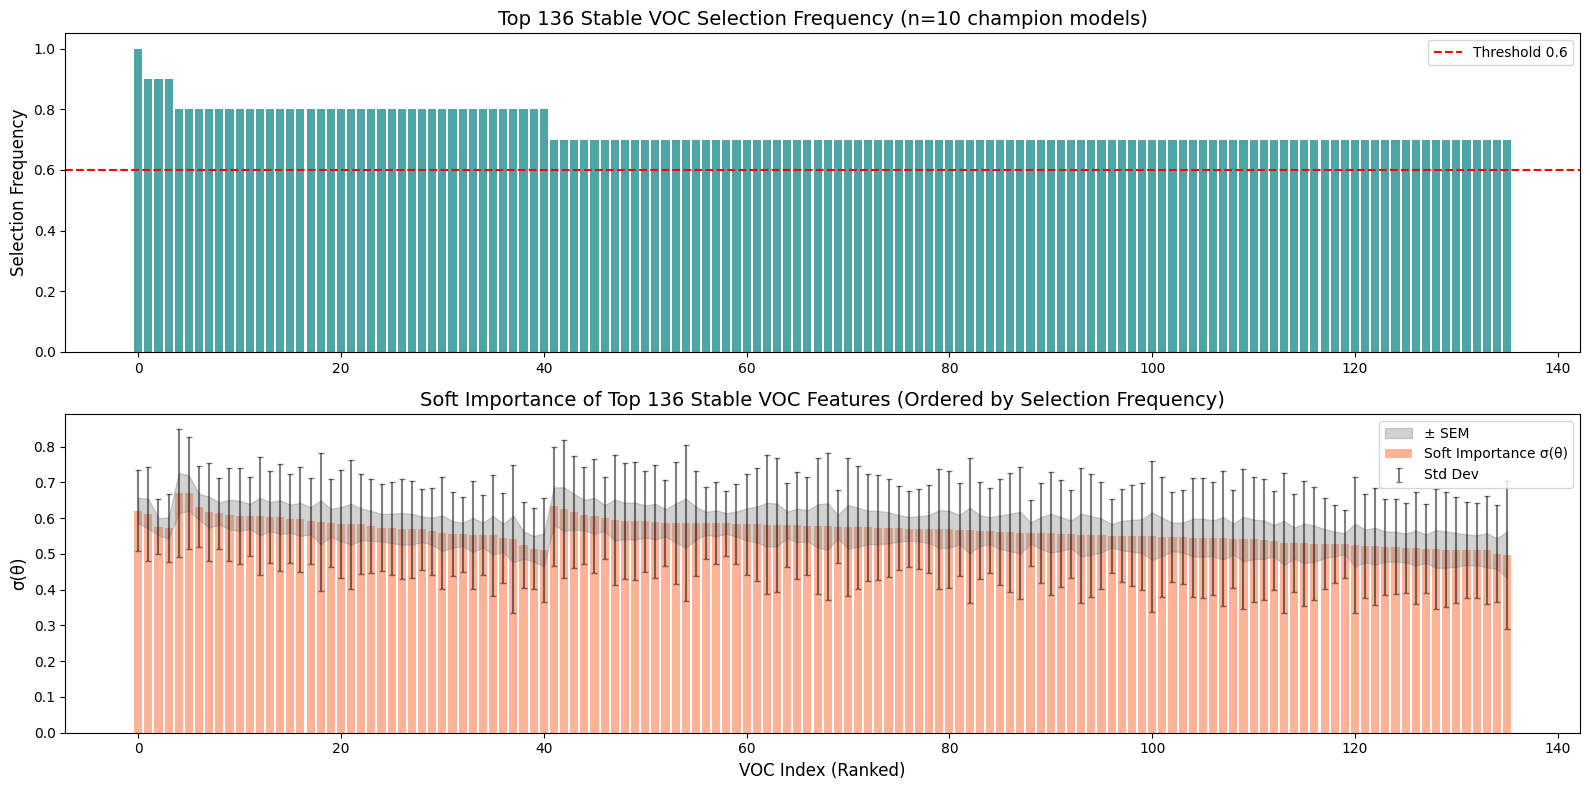

[保存] VOC 图 → ./result/stable_feature_10x10/stable_feature_importance.png


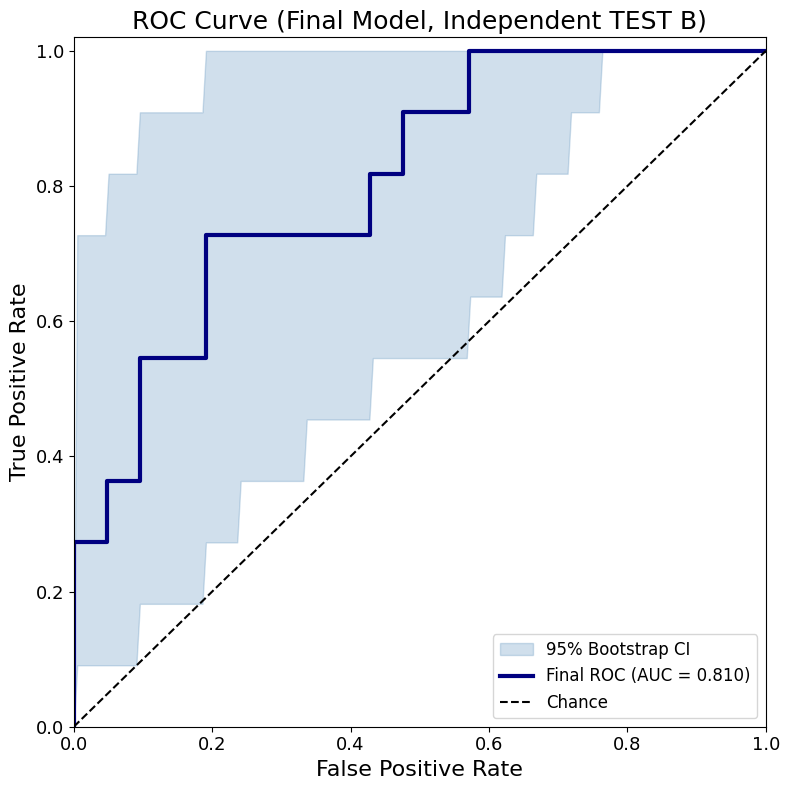

[保存] Final TEST ROC → ./result/stable_feature_10x10/final_test_roc.png
TEST AUC = 0.8095
TEST AUC 95% Bootstrap CI = [0.6320, 0.9437]


FINAL INDEPENDENT TEST B REPORT
测试样本数: 32
稳定特征数: 136
10 次划分 × 10 个模型 = 100 个候选模型
----------------------------------------------------------------------
Sensitivity    0.2727
Specificity    1.0000
PPV            1.0000
NPV            0.7241
Accuracy       0.7500
F1             0.4286
AUC            0.8095
----------------------------------------------------------------------
Confusion Matrix:
[[21  0]
 [ 8  3]]


In [11]:
formal_result = experiment(
    './data/voc_dataset_1+2_vs_3.mat',
    './result/stable_feature_10x10/all_masks.pt',

    num_cluster=3,

    # 开发集 A 内随机划分 10 次
    experiment_repeats=10,

    # 每次划分训练 10 个独立模型
    repeats=10,

    # 每个模型 30 epoch
    epochs=30,

    sparsity_lambda=1e-2,

    temp_start=1.0,
    temp_end=0.3,

    seed=42,

    # 稳定 VOC：选择频率严格 > 60%
    panel_threshold=0.6,

    # TEST ROC Bootstrap
    roc_bootstrap=1000,
)